# Constrained Optimization Algorithms

In this section, we will briefly look at some of the most common constrained optimization algorithms.
This material is covered at a high-level, focusing on the key algorithmic components of constrained optimization methods.

## Penalty Methods and Augmented Lagrangian Methods

A straightforward approach to solving a constrained optimization problem is to add a penalty term for the infeasibility to the objective function, creating a penalty function.
This results in an unconstrained optimization problem that can be solved with unconstrained optimization algorithms.
Often, to get an accurate answer, a sequence of problems solved for increasing penalty parameter.
One challenge that can arise in some problems is that the unconstrained penalty function can have high curvature,  especially with stricter values of the penalty parameter.

Software: Lancelot (Conn, Gould, and Toint), MINOS (Saunders and Murtagh)

There are two types of penalty function methods:

* Inexact penalty functions: The minimizer of the penalty function approximates the constrained minimizer, inexactly. The true constrained solution is only obtained in the limit.

* Exact penalty functions: For sufficiently strict values of the penalty parameter, the minimizer of the exact penalty function is the true constrained minimizer.

### Inexact Penalty Methods

Types of penalty functions:

1. Exterior penalty methods: Exterior penalty functions are defined everywhere within the design domain.

Example: Quadratic penalty function:

\begin{equation*}
\min_{x} f(x) + \frac{\rho}{2} \sum_{i=1}^{m} \max(c_{i}(x), 0)^2
\end{equation*}

2. Interior penalty methods: Defined only where the constraints are feasible.

Example: Log-barrier function

\begin{equation*}
\min_{x} f(x) - \mu \sum_{i=1}^{m} \ln( -c_{i}(x))
\end{equation*}

Note that the log barrier function requires that $c_{i}(x) < 0$ strictly feasible points, otherwise the $\ln( - c_{i}(x))$ term is undefined

To examine the behavior of different penalty functions, find the minimizer and compare to the KKT conditions.
First, differentiate the penalty functions

* Quadratic penalty function

\begin{equation*}
\nabla f(x) + \rho \sum_{i=1}^{m} \max(c_{i}(x), 0) \nabla c_{i}(x) = 0
\end{equation*}

When all of the constraints are active such that $c_{i}(x) \le 0$, then we can simplify this expression

\begin{equation*}
\nabla f(x) + \rho A(x)^{T} c(x) = 0
\end{equation*}

By analogy with the KKT conditions, $\lambda \approx \rho c(x)$.

* Log-barrier function:

\begin{equation*}
\nabla f(x) - \sum_{i=1}^{m} \nabla c_{i} \frac{\mu}{c_{i} (x)} = 0
\end{equation*}

By analogy with the KKT conditions, $\lambda \approx - \mu/c(x)$

### Examples

To observe the effect of the quadratic and log-barrier methods consider the one-dimensional problem:

\begin{equation*}
\begin{aligned}
\min \qquad & x^2 + 3x \\
\text{such that} \qquad & x \ge 0
\end{aligned}
\end{equation*}

The solution of the problem is:

\begin{equation*}
x^{*} = 0,\; \lambda^{*} = 3, \qquad
%
x^{Q} = \frac{-3}{(2 + \rho)}, \qquad
%
x^{B} = \frac{1}{4}(-3 + \sqrt{9 +8\mu})
\end{equation*}

Next, consider the following two-dimensional problem, again with the quadratic penalty function and log-barrier methods:

\begin{equation*}
\begin{aligned}
\min \qquad & \frac{1}{2}(x_1^2 + x_2^2) + (x_1 + x_2) \\
\text{such that} \qquad & x_1 + x_2 \ge 0
\end{aligned}
\end{equation*}

The exact solution and quadratic/barrier solutions are:

\begin{equation*}
x^{*} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}\; \lambda^{*} = 1, \;\;
%
x^{Q} = -\frac{1}{1 + 2\rho} \begin{bmatrix} 1 \\ 1 \end{bmatrix} \;\;
%
x^{B} = \frac{1}{4}(-2 + \sqrt{4 +8\mu}) \begin{bmatrix} 1 \\ 1 \end{bmatrix} 
\end{equation*}

Consider the following constrained optimization problem:

\begin{equation*}
\begin{aligned}
\min \qquad & \frac{1}{2}(x_{1}^2 + x_{2}^2) - 2x_{1} - 2x_{2} \\
\text{such that} \qquad & x_{1}^2 + x_{2}^2 - 1/2 \le 0
\end{aligned}
\end{equation*}

\begin{equation*}
x^{*} = 
\frac{1}{2}
\begin{bmatrix}
1 \\
1 \\
\end{bmatrix}
\qquad
\lambda_{1}^{*} = \frac{3}{2}
\end{equation*}

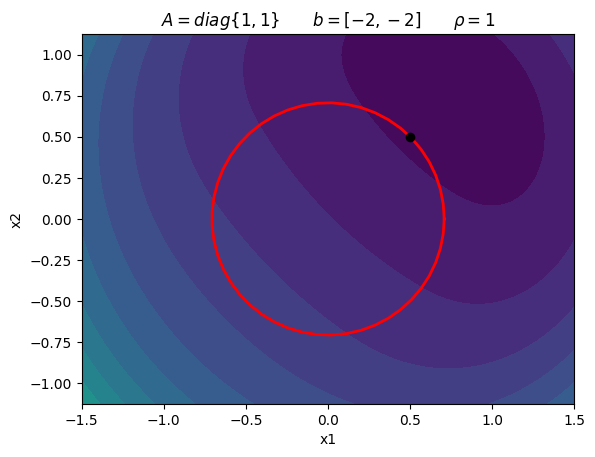

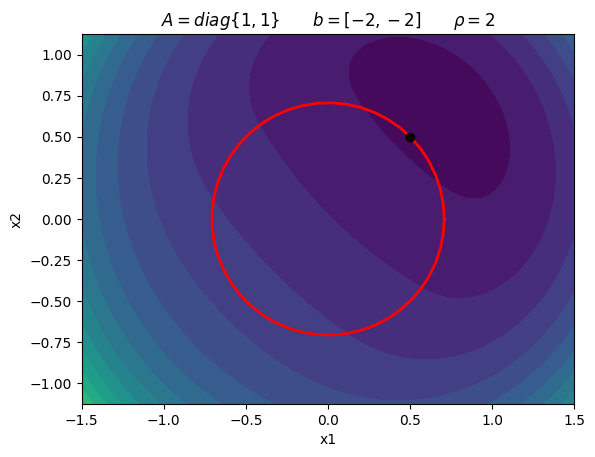

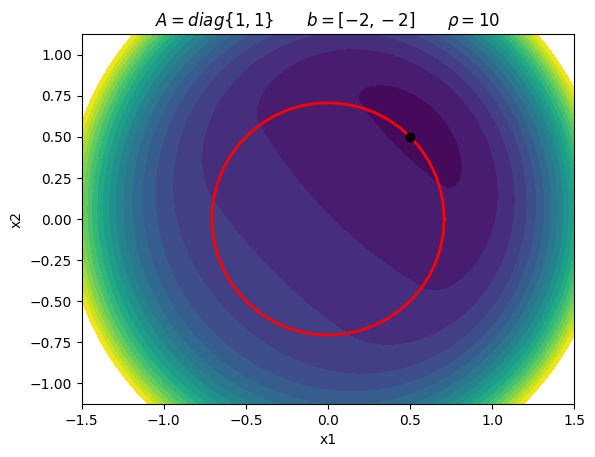

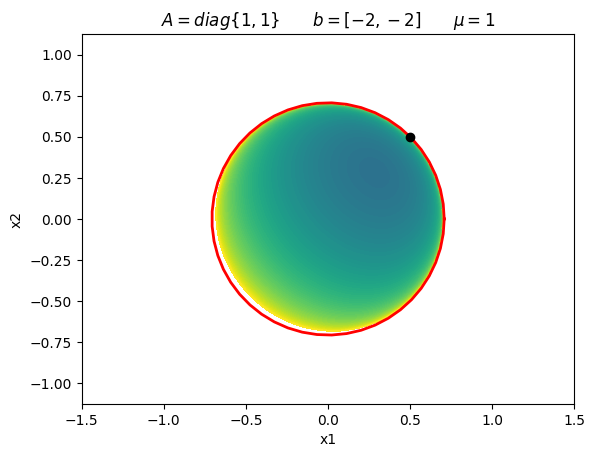

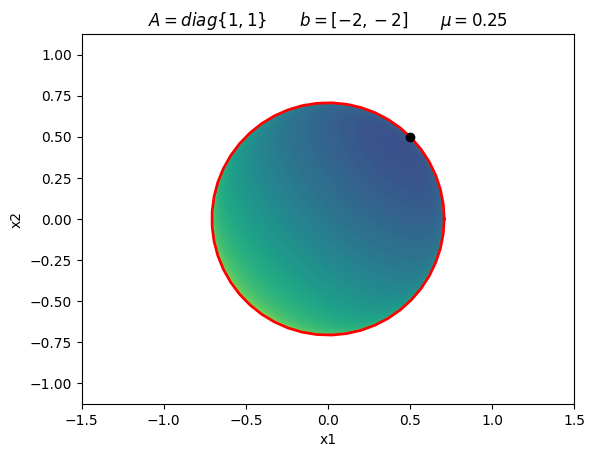

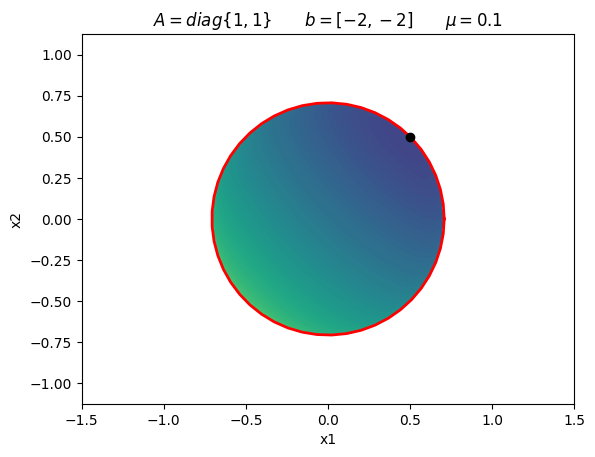

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_quadratic_penalty(A, b, rho, xdim=1.5):
    # Generate plot
    n = 250
    x = np.linspace(-xdim, xdim, n)
    y = np.linspace(-0.75*xdim, 0.75*xdim, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = np.array([X[i,j], Y[i,j]])
            f[i, j] = 0.5*np.dot(x, np.dot(A, x)) + np.dot(x, b) + 0.5*rho*np.max((0, x[0]**2 + x[1]**2 - 0.5))**2

    fig, ax = plt.subplots(1, 1)
    levels = 20
    ax.contourf(X, Y, f, levels=np.linspace(-3, 25, 20))
    plt.xlabel('x1')
    plt.ylabel('x2')
    ax.set_aspect('equal', 'box')
    return

def plot_log_barrier(A, b, mu, xdim=1.5):
    # Generate plot
    n = 250
    x = np.linspace(-xdim, xdim, n)
    y = np.linspace(-0.75*xdim, 0.75*xdim, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = np.array([X[i,j], Y[i,j]])
            c1 = x[0]**2 + x[1]**2 - 0.5
            if c1 < 0.0:
                f[i, j] = 0.5*np.dot(x, np.dot(A, x)) + np.dot(x, b) - mu*np.log(-c1)
            else:
                f[i, j] = 1e20

    fig, ax = plt.subplots(1, 1)
    levels = 20
    ax.contourf(X, Y, f, levels=np.linspace(-3, 5, 100))
    plt.xlabel('x1')
    plt.ylabel('x2')
    ax.set_aspect('equal', 'box')
    
    return

# Example 1
A = np.array([[1.0, 0.0], [0.0, 1.0]])
b = np.array([-2.0, -2.0])
plot_quadratic_penalty(A, b, 1.0)
plt.title(r'$A = diag\{1, 1\} \qquad b = [-2, -2] \qquad \rho = 1$')

theta = np.linspace(0, 2*np.pi)
x = np.sqrt(0.5)*np.cos(theta)
y = np.sqrt(0.5)*np.sin(theta)
plt.plot(x, y, 'r', linewidth=2)
plt.plot([0.5], [0.5], 'ko')

A = np.array([[1.0, 0.0], [0.0, 1.0]])
b = np.array([-2.0, -2.0])
plot_quadratic_penalty(A, b, 2.0)
plt.title(r'$A = diag\{1, 1\} \qquad b = [-2, -2] \qquad \rho = 2$')

theta = np.linspace(0, 2*np.pi)
x = np.sqrt(0.5)*np.cos(theta)
y = np.sqrt(0.5)*np.sin(theta)
plt.plot(x, y, 'r', linewidth=2)
plt.plot([0.5], [0.5], 'ko')

A = np.array([[1.0, 0.0], [0.0, 1.0]])
b = np.array([-2.0, -2.0])
plot_quadratic_penalty(A, b, 10.0)
plt.title(r'$A = diag\{1, 1\} \qquad b = [-2, -2] \qquad \rho = 10$')

theta = np.linspace(0, 2*np.pi)
x = np.sqrt(0.5)*np.cos(theta)
y = np.sqrt(0.5)*np.sin(theta)
plt.plot(x, y, 'r', linewidth=2)
plt.plot([0.5], [0.5], 'ko')

# Example 1
A = np.array([[1.0, 0.0], [0.0, 1.0]])
b = np.array([-2.0, -2.0])
plot_log_barrier(A, b, 1.0)
plt.title(r'$A = diag\{1, 1\} \qquad b = [-2, -2] \qquad \mu = 1$')

theta = np.linspace(0, 2*np.pi)
x = np.sqrt(0.5)*np.cos(theta)
y = np.sqrt(0.5)*np.sin(theta)
plt.plot(x, y, 'r', linewidth=2)
plt.plot([0.5], [0.5], 'ko')

A = np.array([[1.0, 0.0], [0.0, 1.0]])
b = np.array([-2.0, -2.0])
plot_log_barrier(A, b, 0.25)
plt.title(r'$A = diag\{1, 1\} \qquad b = [-2, -2] \qquad \mu = 0.25$')

theta = np.linspace(0, 2*np.pi)
x = np.sqrt(0.5)*np.cos(theta)
y = np.sqrt(0.5)*np.sin(theta)
plt.plot(x, y, 'r', linewidth=2)
plt.plot([0.5], [0.5], 'ko')

A = np.array([[1.0, 0.0], [0.0, 1.0]])
b = np.array([-2.0, -2.0])
plot_log_barrier(A, b, 0.1)
plt.title(r'$A = diag\{1, 1\} \qquad b = [-2, -2] \qquad \mu = 0.1$')

theta = np.linspace(0, 2*np.pi)
x = np.sqrt(0.5)*np.cos(theta)
y = np.sqrt(0.5)*np.sin(theta)
plt.plot(x, y, 'r', linewidth=2)
plt.plot([0.5], [0.5], 'ko')

plt.show()

### Exact Penalty Methods

Exact penalty functions give the exact minimizer when the penalty function is sufficiently strict, but finite.
In other words, we do not have to take the limit as $\mu \rightarrow 0$ or $\rho \rightarrow \infty$ to get the true constrained minimizer.
In this section, we'll look at two exact penalty functions: the $\ell_{1}$ penalty function and the augmented Lagrangian function.

* The $\ell_{1}$ penalty function takes the form:

\begin{equation*}
\min_{x} f(x) + \rho \sum_{i=1}^{m} \max(c_{i}(x), 0)
\end{equation*}

Note that the penalty function is not differentiable at $c_{i}(x) = 0$ due to the $\max$ function.
When $\rho \ge \max_{i} \lambda_{i}$, then the minimizer is exact.

A common approach is to take the $\ell_{1}$ penalty function and to reformulate it using slack variables:

\begin{equation*}
\begin{aligned}
\min_{x,s,t} \qquad & f(x) + \rho \sum_{i=1}^{m} s_{i} \\
\text{such that} \qquad & c_{i}(x) = s_{i} - t_{i} \\
& s_{i} \ge 0 \\
& t_{i} \ge 0 \\
\end{aligned}
\end{equation*}

This reformulation has removed the non-differentiable $\max$ value function.
However, we have introduced additional slack variables $s_{i}, t_{i} \ge 0$ and introduced equality constraints and inequality bounds on the slack variables.

* Augmented Lagrangian function:

The augmented Lagrangian function can be used for both equality and inequality constraints.
Here, we focus on the form taken for equality constraints $h(x) = 0$. 
There are various inequality methods that generally use some type of slack variable reformulation.
For the equality-constrained problem, the augmented Lagrangian takes the form

\begin{equation*}
\min_{x} f(x) + \lambda^{T} h(x) + \frac{\rho}{2} h(x)^{T}h(x)
\end{equation*}
    
The values of $\lambda$ are Lagrange multiplier estimates. The minimum is exact for finite $\rho$ if $\lambda$ are accurate estimates of the multipliers.

### Examples

\begin{equation*}
\begin{aligned}
\min \qquad & x^2 + 3x \\
\text{such that} \qquad & x \ge 0
\end{aligned}
\end{equation*}

The solution is:

\begin{equation*}
x^{*} = 0,\; \lambda^{*} = 3
\end{equation*}

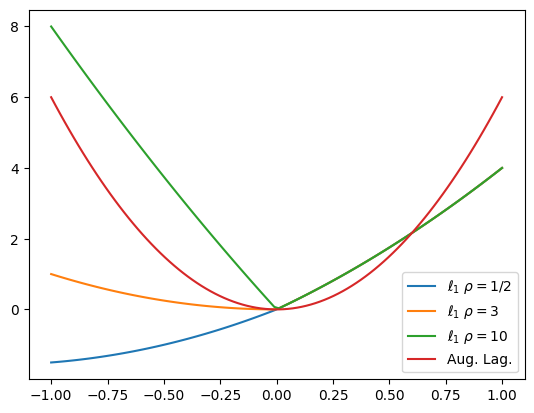

In [7]:
import numpy as np
import matplotlib.pylab as plt

def f(x):
    return x**2 + 3*x

def l1_penalty(xval, rho):
    return f(xval) + rho*np.max((-xval, 0))

def aug_lagrange(xval, lam, rho):
    return f(xval) + lam*xval + 0.5*rho*xval**2
    
n = 100
x = np.linspace(-1, 1, n)
l1_05 = np.zeros(n)
l1_3 = np.zeros(n)
l1_10 = np.zeros(n)
aug_lag = np.zeros(n)

lam = -3.0

for i in range(n):
    l1_05[i] = l1_penalty(x[i], 0.5)
    l1_3[i] = l1_penalty(x[i], 3)
    l1_10[i] = l1_penalty(x[i], 10)
    aug_lag[i] = aug_lagrange(x[i], lam, 10.0)

plt.figure()
plt.plot(x, l1_05, label=r'$\ell_{1}$ $\rho = 1/2$')
plt.plot(x, l1_3, label=r'$\ell_{1}$ $\rho = 3$')
plt.plot(x, l1_10, label=r'$\ell_{1}$ $\rho = 10$')
plt.plot(x, aug_lag, label='Aug. Lag.')
plt.legend()
plt.show()


## Sequential Quadratic Optimization (Sequential Quadratic Programming)

Sequential Quadratic Programming (SQP) or Sequential Quadratic Optimization (SQO) methods solve a sequence of quadratic optimization problems at each iteration of the algorithm.
These subproblems utilize a quadratic model of the objective, including the effect of constraint curvature in the Lagrangian, and linearize the constraints.
Some implementations keep an estimate of the active set of constraints (the working set).
SQP or SQO methods can be combined with line search methods or trust region methods for globalization.
    
Software: SNOPT (Gill, Murray, and Saunders), FilterSQP (Fletcher, Leyffer and Chin), CPLEX (IBM).
    
* At each iteration, SQP methods solve a quadratic programming problem:

\begin{equation*}
\begin{aligned}
\min_{p_{x}} \qquad & f(x) + \nabla f^{T}p_{x} + \frac{1}{2} p_{x}^{T} B p_{x} \\ 
\text{such that} \qquad & c(x) + A p_{x} \le 0
\end{aligned}
\end{equation*}
    
* $B \approx \nabla^2 \mathcal{L}$ is a Hessian approximation
* Predicts step $p_{x}$, and the new Lagrange multiplier estimates $\lambda$

SQP methods are mature, robust and efficient and very good implementations exist.

### Infeasible quadratic subproblems

When starting from an infeasible design point, the linearized constraint functions may not yield a subproblem with a feasible point.
Infeasible subproblems must be handled, otherwise the solution to the SQP subproblem cannot be found.
To address this issue, some SQP methods solve a different problem when an infeasible subproblem is encountered, like this:

\begin{equation*}
\begin{aligned}
\min_{p_{x}, t} \qquad & f(x) + \nabla f^{T}p_{x} + \gamma \sum_{i=1}^{m} t_{i}\\ 
\text{such that} \qquad & c(x) + A p_{x} - t \le 0 \\
& t \ge 0
\end{aligned}
\end{equation*}

Here the goal is to find a step that restores feasibility.

## Primal-Dual Interior-Point Methods

Interior-point methods are motivated by interior penalty methods, like the log-barrier penalty function.
However, these methods make a key modification that makes them more robust: They add the Lagrange multipliers as additional unknowns in the optimization problem.
Like log-barrier methods, interior-point methods solve a sequence of problems.
These problems utilize a perturbation of the KKT conditions that approach the true KKT conditions as $\mu \rightarrow 0$.

Numerous optimization algorithms use this approach including: IPOPT (Wachter and Biegler), LOQO (Vanderbei), KNITRO (Byrd and Nocedal).

1984: The interior-point revolution

* Prior to 1984, linear programming was dominated by the simplex method
* Worst-case simplex method running time complexity is exponential $2^{n}$ --- In practice it is much better, but this had a lot of people concerned
* Interior-point methods for linear programming: they converge to a fixed multiple of the solution in polynomial time (good theoretical and practical performance)

Extension to nonlinear programming is well understood.

We will formulate our interior-point method to work on problems like this:

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & f(x) \\
\text{such that} \qquad & h(x) = 0 \\
& x \ge 0
\end{aligned}
\end{equation*}

The inequality constraints have been replaced with equality constraints $h(x) \in \mathbb{R}^{n} \rightarrow \mathbb{R}^{m}$.
There are a set of inequality bound constraints $x \ge 0$ on the variables.
More general constraints can be handled with slack variables.

The design variables $x$ are called the primal variables, and the dual variables are the Lagrange multipliers associated with $h(x) = 0$ and $x \ge 0$, $\lambda$ and $z$, respectively.

Primal-dual methods take steps in both primal and dual variables simultaneously.
Interior-point methods use a sequence of barrier-problems for decreasing penalty parameter $\mu$.

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & \varphi(x) = f(x) - \mu \sum_{i} \ln x_{i} \\
\text{such that} \qquad & h(x) = 0
\end{aligned}
\end{equation*}
  
We will use the following notation: 

* Given the vector $x \in \mathbb{R}^{n}$, $X$ is the diagonal matrix $X \in \mathbb{R}^{n \times n}$ such that:
 
\begin{equation*}
X = \text{diag}\{x_1, x_2,\ldots,x_{n}\}
\end{equation*}

* $e \in \mathbb{R}^{k}$ is the vector of unit entries such that $e_{i} = 1$, for all $i = 1,\ldots,k$

### KKT conditions for the barrier problem

The KKT conditions for the barrier problem are

\begin{equation*}
\begin{aligned}
\nabla f(x) - \mu X^{-1} e - A(x)^{T}\, \lambda & = 0 \\
h(x) & = 0 \\
\end{aligned}
\end{equation*}

Note that we have to enforce $x > 0$ since we're using an interior penalty method.
This is easy, since we control what $x$ is, but more on this soon.
The sign of $\lambda$ not an issue since we're using equality constraints $h(x) = 0$.

### KKT conditions for the original problem

Now consider the KKT conditions for the original problem

\begin{equation*}
\begin{aligned}
\nabla f - z - A(x)^{T}\, \lambda & = 0 \\
h(x) & = 0 \\
Xz & = 0
\end{aligned}
\end{equation*}

The last equation is the complementarity condition.

Given the KKT conditions for the barrier method, make the following substitutions:

* Define $z = \mu X^{-1}e$
* Multiply the last equation through by $X$, we get $X z = \mu e$

Applying these substitutions to the barrier problem, we get:

\begin{equation*}
\begin{aligned}
\nabla f - z - A(x)^{T} \, \lambda & = 0 \\
h(x) & = 0 \\
Xz & = \mu e
\end{aligned}
\end{equation*}

* These are the perturbed KKT conditions for the original problem
* As $\mu \rightarrow 0$, we recover the original 

* Interior-point methods solve a sequence of barrier problems for decreasing $\mu$
* We explicitly enforce $x > 0$, $z > 0$, therefore we are in the feasible region. This is straightforward to do since $x$ and $z$ are variables that we control.

At no point do we have to worry about the active set. The active set of constraints arises naturally from the  complementarity condition.

### Approximate Newton method for the barrier problem

Writing the nonlinear KKT system of equations for the barrier problem as follows:

\begin{equation*}
\begin{aligned}
\nabla f - z - A(x)^{T}\, \lambda & = 0 \\
h(x) & = 0 \\
Xz - \mu e & = 0 \\
\end{aligned}
\end{equation*}

We can compute an update as follows using Newton's method:

\begin{equation*}
\begin{bmatrix}
B & -A^{T} & -I \\
A & 0 & 0 \\
Z & 0 & X \\
\end{bmatrix}
\begin{bmatrix}
p_x \\
p_\lambda \\
p_z
\end{bmatrix}
= - 
\begin{bmatrix}
\nabla_{x} f(x) - z - \nabla_{x} h(x)\, \lambda  \\
h(x) \\
Zx - \mu e \\
\end{bmatrix}
\end{equation*}

* $A = \nabla h$ is the constraint Jacobian
* $B \approx \nabla_{x}^2 \mathcal{L}$ is a quasi-Newton Hessian approximation

The convergence criterion is based on the maximum value of the KKT violation

\begin{equation*}
E(x, \lambda, z; \mu) = \max \left\{ 
|| \nabla f(x) - z - A(x)^{T} \lambda||_{\infty}, \; 
||c(x)||_{\infty}, \; ||Xz - \mu e||_{\infty}\right\}
\end{equation*}

* We have to solve a sequence of barrier problems with decreasing $\mu$ to recover the KKT conditions
* What tolerance should we use for each barrier problem?
* How should we update the barrier parameter?
* Fiacco and McCormick approach: Solve barrier problem (approximately) and then decrease $\mu$ by a constant factor

### Maintaining positive $x$ and $z$

We have to maintain positive $x$ and $z$ for the interior point method to work. How do we enforce this? 

Compute a maximum step length, then use a backtracking method from the initial point.
Instead of taking the step all the way to the boundary (e.g. $x = 0$), we impose a condition that we only approach the boundary to  within a fixed fraction of the original value of $x$
Mathematically this looks like this:

\begin{equation*}
\begin{aligned}
\alpha_{z} & = \max \left\{ \alpha \in (0, 1] \;|\; z + \alpha p_{z} \ge (1 - \tau)z \right\},  \\
\alpha_{x} & = \max \left\{ \alpha \in (0, 1] \;|\; x + \alpha p_{x} \ge (1 - \tau)x \right\},  
\end{aligned}
\end{equation*}
  
* $\tau = 0.99$ or $\tau = 0.995$ are common
* We then perform a line search along the direction:
  
\begin{equation*}
(x, \lambda, z) + \alpha (\alpha_{x} p_{x}, \alpha_{z} p_{\lambda}, \alpha_{z} p_{z}),
\end{equation*}

<!-- \begin{frame}
  \begin{center}
  \includegraphics[width=0.75\textwidth]{figures/ip_method_feasible_step}
  \end{center}
\end{frame}
 -->
 
### Barrier line search

The line search we use with each barrier problem is based on the following merit function:
  
\begin{equation*}
\mathcal{M}(x;\rho) = f(x) - \mu \sum_{i=1}^{n} \ln x_{i} + \rho ||h(x)||_{2}
\end{equation*}

* Based on this function, we use the following merit function for $\alpha \in (0, 1]$:

\begin{equation*}
\phi(\alpha; \rho) =  \mathcal{M}(x + \alpha \alpha_{x} p_{x}; \rho)
\end{equation*}

We take a step to the new primal-dual point $(x + \alpha \alpha_x p_{x}, \lambda + \alpha \alpha_{z} p_{\lambda}, z + \alpha \alpha_{z} p_{z})$. 
The new point has no new components less than or equal to zero in $x$ or $z$.

## Key Features of Constrained Optimization

In this section, we examine some key common features of constrained optimization algorithms.

### Measuring progress: Merit Functions and Filtering

For unconstrained optimization, both line search methods and trust region methods relied on measuring progress through $f(x)$.
This worked well because our only goal was to improve the objective function value.
However, now we have both the objective function and constraints.
A new point may improve the objective function value at the expense of an increase in the constraint violation.

* How can we measure progress when we have both $f(x)$ and $c(x)$?

There are different approaches to this issue. We'll look at two common approaches: merit functions and filters.
These methods are important for *globalization*: Ensuring that the algorithm will converge from starting points that are far from the optimal solution.

#### Merit functions

Merit functions are functions that combine both the objective and constraint information into a single value.
The goal is then to use a combination of the objective value and constraint violation.

* Ensure reduction in the merit function at each step
* Similar to penalty methods: We have exact and inexact line search methods
* Exact $\ell_1$ penalty function:

\begin{equation*}
\phi(x) = f(x) + \rho \sum_{i} \max(0, c_{i}(x)) 
\end{equation*}

* This approach will work with either line search methods or trust region methods

* In practice a sufficient decrease condition can be used for the line search method

\begin{equation*}
\phi(x + \alpha p) \le \phi(x) + c_{1} \alpha D\phi(x)
\end{equation*}

* Here $D\phi(x_{k})$ is a directional derivative
* Note that we pick the value of $\rho$ for the merit function $\phi(x)$ at each iteration. Often $\rho$ changes at every iteration.
* We will choose a value to make sure that we have a descent direction in $\phi(x + \alpha p)$
*  $D\phi(x)$ will depend on how we pick $p$

#### Filters

Filter methods are an alternative to line search methods.
Fitler methods are successful in practical constrained optimization algorithms, for instance IPOPT and FilterSQP use them.
The concept of a filter is based on Pareto optimality from multi-objective optimization.
A point in the filter is designed to represent the best tradeoff between improving the objective function and improving the constraint violation seen so far during the optimization.
The filter separates the objective and infeasibility contributions:

\begin{equation*}
\text{obj 1:} \;\; f(x) \qquad \qquad \text{obj 2:} \;\; h(x) = \sum_{i} \max(0, c_{i}(x))
\end{equation*}

The function $h(x)$ is a measure of the constraint violation. 

The filter stores pairs of points $(h(x_{i}), f(x_{i})) = (h_i, f_i)$.
A point $(h_k, f_k)$ *dominates* $(h_i, f_i)$ if

\begin{equation*}
h_k < h_i \qquad \text{and} \qquad f_k < f_i
\end{equation*}

This concept of a dominant point is from Pareto optimality.
The pairs of points stored in the filter do not dominate each other.
A new point encountered in the optimization is accepted only if it is not dominated by any previous point.

A straightforward application of the filter method to a line search algorithm works as follows:

1. Given a descent direction $p$ and an initial $\alpha$ value
2. Evaluate the objective function $f_{t} = f(x + \alpha p)$ and the constraint violation $h_{t} = h(x + \alpha p)$
3. If either $h(x_{k}) < h_{i}$ or $f(x_{k}) < f_{i}$ for each point $(h_{i}, f_{i})$ in the filter than the new point $x + \alpha p$ is accepted in the filter.
4. Remove all points from the filter that are dominated by $(h_t, f_t)$.

A refinement on the filter, required for making sufficient progress: require a sufficient decrease (slanting envelope).  Accept a new point if either:

\begin{equation*}
h(x) \le \beta h_{i} \qquad \text{or} \qquad f(x) + \gamma h_{i} \le f_{i} 
\qquad \text{for all i}
\end{equation*}

Here the constants must be greater than zero $\beta >0$, $\gamma > 0$.
If a step is accepted, it is added to the filter and dominated points are removed.
Dominated points: $f(x) \le f_{i}$ \emph{and} $h(x) \le h_{i}$ $\implies$ the pair $(h_i, f_i)$ should be removed.

The filter may require arbitrarily small steps, which impedes progress and the algorithm may stall.
In practice, a *feasibility restoration phase* must also be included in the optimization algorithm. The feasibility restoration phase involves minimizing $h(x)$


<img src="filter_methods.png">

<!-- 
\begin{frame}
  \frametitle{Filter method}
  {\small
  \begin{algorithmic}
    \State{Choose a starting point $x_{1}$ and a constant $\tau < 1$}
    \State{Initialize the filter $\mathcal{F} = \emptyset$ and set $k = 1$}
    %
    \While{Convergence test \emph{not} satisfied}
    %
    \State{Generate a step direction $p_{k}$}
    \State{Set $i = 1$, $\alpha_1 = 1$}
    %
    \While{$i <$ maximum line search iterations}
    \Comment{Filter line search}
    \State{Compute $x^{+} = x_{k} + \alpha_{i} p_{k}$ and evaluate $f(x^{+})$ and $h(x^{+})$}
    \If{the pair $(h(x^{+}), f(x^{+}))$ is accepted by the filter}
    \State{Remove all pairs from $\mathcal{F}$ dominated by the pair $(h(x^{+}), f(x^{+}))$}
    \State{Add the pair to the filter $\mathcal{F} = \mathcal{F}\cup(h(x^{+}), f(x^{+}))$}
    \State{Set $x_{k+1} = x^{+}$}
    \State{{\bf break}}
    \EndIf
    %
    \State{Compute $\alpha_{i+1} = \tau \alpha_{i}$}
    \State{Set $i \leftarrow i+1$}
    \EndWhile
    %
    \State{Set $k \leftarrow k + 1$}
    \EndWhile
  \end{algorithmic}}
\end{frame} -->

### The Maratos effect

Merit functions and filter methods suffer from the Maratos effect.
Note that some augmented Lagrangian merit function do not suffer from the Maratos effect, but we won't cover these here.

The Maratos effect occurs because we typically only use a linearization of the constraints in predicting the next step. We then use the nonlinear constraint in the filter or line search to decide whether to accept the step. As a result, steps which make good progress towards the solution may be rejected by the merit function/filter since both infeasibility and the objective can increase for steps that make good progress: $f(x + p_x)$ and $c(x + p_x)$.

* One solution: Compute a corrective step $\hat{p}_{k}$ with $A_{k} = \nabla c(x_{k})^{T}$ as the minimum-norm solution of:

\begin{equation*}
A_{k}\hat{p}_{k} + c(x + p_{k}) = 0
\end{equation*}

Solution: 

\begin{equation*}
\hat{p}_{k} = - A_{k}^{T}(A_{k}A_{k}^{T})^{-1}c(x_{k} + p)
\end{equation*}

Typical approach: If infeasibility increases at $x_{k}+p_{k}$, try the second-order correction at $x_{k} + p_{k} + \hat{p}_{k}$. 
If merit function does not satisfy sufficient decrease there, discard $\hat{p}_{k}$ and do remaining line search
    using $p_{k}$.

Consider the optimization problem:

\begin{equation*}
\begin{aligned}
\min \qquad & 2(x_{1}^2 + x_{2}^{2} - 1) - x_1 \\
\text{s.t.} \qquad & x_{1}^2 + x_{2}^{2} - 1 = 0 \\
\end{aligned}
\end{equation*}

Due to the curvature of the constraints, steps that start from points close to the constraint boundary that make good progress towards the constrained minimizer may be rejected since they increase both he objective function and constraint infeasibility.


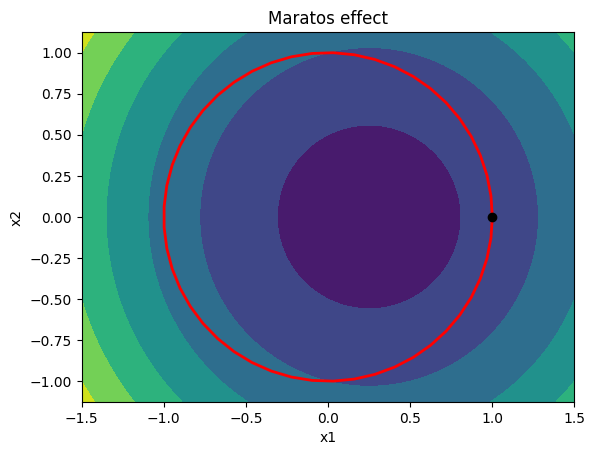

In [8]:
import numpy as np
import matplotlib.pylab as plt

def plot_quadratic(A, b, c, xdim=1.5):
    # Generate plot
    n = 250
    x = np.linspace(-xdim, xdim, n)
    y = np.linspace(-0.75*xdim, 0.75*xdim, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = np.array([X[i,j], Y[i,j]])
            f[i, j] = 0.5*np.dot(x, np.dot(A, x)) + np.dot(x, b) + c

    fig, ax = plt.subplots(1, 1)
    levels = 20
    ax.contourf(X, Y, f)
    plt.xlabel('x1')
    plt.ylabel('x2')
    ax.set_aspect('equal', 'box')
    return

A = np.array([[4.0, 0.0], [0.0, 4.0]])
b = np.array([-1.0, 0.0])
plot_quadratic(A, b, -0.5)
plt.title(r'Maratos effect')

theta = np.linspace(0, 2*np.pi)
x = np.cos(theta)
y = np.sin(theta)
plt.plot(x, y, 'r', linewidth=2)
plt.plot([1.0], [0.0], 'ko')

plt.show()


<!--  
\begin{frame}
  \frametitle{Line search for constrained optimization}

  \begin{itemize}
  \item When performing line searches with constrained
    optimization, we need to protect against the Maratos effect
  \item Note that $D\phi(x, \rho)$ is the directional derivative 
  \end{itemize}

  {\scriptsize
  \begin{algorithmic}
    \State{Choose a starting point $x_{1}$, a constant $\tau < 1$ and $c_{1}$}
    %
    \While{Convergence test \emph{not} satisfied}
    %
    \State{Generate a step direction $p_{k}$}
    \State{Set $i = 1$, $\alpha_1 = 1$}
    %
    \While{$i <$ maximum iterations}
    \Comment{Second-order corrected line search}
    \State{Compute $x^{+} = x_{k} + \alpha_{i} p_{k}$ and evaluate $f(x^{+})$ and $c(x^{+})$}
    %
    \If{$\phi(x^{+}) \le \phi(x_{k}) + c_1 \alpha_{i} D\phi(x_{k}; \rho)$}
    \State{Set $x_{k+1} \leftarrow x^{+} (= x_{k} + \alpha_{i} p_{k})$}
    \State{{\bf break}}
    %
    \ElsIf{$i == 1$}
    \State{Compute $\hat{p}_{k}$}
    %
    \If{$\phi(x_{k} + p_{k} + \hat{p}_{k}) \le \phi(x_{k}) + c_1 \alpha_{i} D\phi(x_{k}; \rho)$}
    \State{Set $x_{k+1} \leftarrow x_{k} + p_{k} + \hat{p}_{k}$}
    \State{{\bf break}}
    \EndIf
    %
    \EndIf
    %
    \State{Compute $\alpha_{i+1} = \tau \alpha_{i}$}
    \State{Set $i \leftarrow i+1$}
    \EndWhile
    %
    \State{Set $k \leftarrow k + 1$}
    \EndWhile
  \end{algorithmic}}
\end{frame}
 -->
 
## Pointers for using Constrained Optimization Algorithms

In this section, we'll look briefly at some practical aspects of using constrained optimization algorithms.

SLSQP is a sequential quadratic programming method that is available through scipy. It's relative easy to use. It can be difficult to understand errors though. 

SLSQP is an old fortran code that uses a BFGS update scheme with an $\ell_{1}$ penalty function. The full code is available here:

https://github.com/jacobwilliams/slsqp

However, this code generates little in the way of output and it can be challenging to sort out what it is doing.

Other common optimization codes are:

1. SNOPT: https://web.stanford.edu/group/SOL/guides/sndoc7.pdf
2. IPOPT: https://github.com/coin-or/Ipopt or https://en.wikipedia.org/wiki/IPOPT
3. Knitro: https://en.wikipedia.org/wiki/Artelys_Knitro
4. CPLEX: https://www.ibm.com/products/ilog-cplex-optimization-studio/cplex-optimizer

My group's code called ParOpt: https://github.com/smdogroup/paropt


### Optimizer checklist for success

Once you have debugged the code and it runs, you should do the following:

1. Check your gradient! If you provide a gradient this can be much faster than using finite-difference methods. But you need to ensure that your gradient is correct and consistent with the function.
2. Check your variable bounds. You may find that the optimizer doesn't find a feasible point. It's a good idea to try to adjust bounds to try and achieve an initial feasible point. But the bounds may not be enough.
3. Check if your constraints are consistent and can result in a feasible point. Remove constraints then gradually add them back into the problem until you find a feasible point. 

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.09853493376797083
           x: [ 6.868e-01  4.696e-01]
         nit: 23
         jac: [-4.724e-02 -4.216e-01]
        nfev: 78
        njev: 23
 multipliers: [ 1.138e-01  0.000e+00]


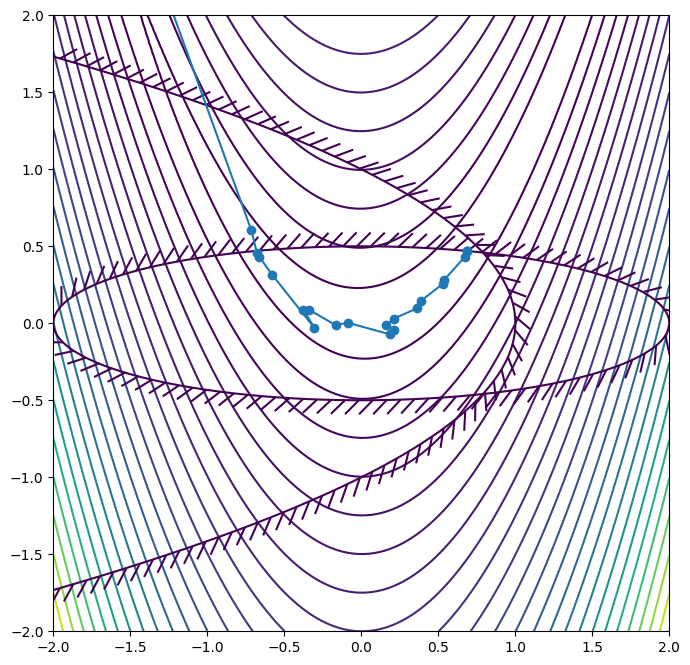

In [9]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pylab as plt
from matplotlib import patheffects

def plot_contour(func, xlow=-2, xhigh=2,
                 ylow=-2, yhigh=2, n=200, nonlinear=False):
    """Create a contour plot of the function"""

    # Plot the contours of the function
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = [X[i, j], Y[i, j]]
            f[i, j] = func(x)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    levels = np.linspace(np.min(f), np.max(f), 25)
    if nonlinear:
        levels = np.min(f) + (np.max(f) - np.min(f))*np.linspace(0, 1.0, 25)**2
    ax.contour(X, Y, f, levels=levels)
    ax.set_aspect('equal', 'box')

    return fig, ax

def plot_constraint(ax, con, xlow=-2, xhigh=2,
                    ylow=-2, yhigh=2, n=200, **kwargs):
    """Create a contour plot of the constraint"""

    # Plot the contours of the function
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    c = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = [X[i, j], Y[i, j]]
            c[i, j] = con(x)

    c1 = ax.contour(X, Y, -c, [0.0], **kwargs)
    c1.set(path_effects=[patheffects.withTickedStroke()])

    return

xhist = []
def callback(xk):
    xhist.append(np.array(xk))
    pass
    
# The objective
def objective(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

# The constraint - here scipy uses the constraint form c(x) >= 0!
def con1(x):
    return 1.0 - 0.25 * x[0]**2 - 4.0 * x[1]**2

def con2(x):
    return 1.0 - x[0] - x[1]**2

constraints = [
    {"type": "ineq", "fun" : con1}, 
    {"type": "ineq", "fun" : con2}]

# Lower and upper bounds on the design variables - here there are no bounds!
bounds = [(None, None), (None, None)]

# Starting point
x0 = np.array([-1.0, -1.0])
res = minimize(objective, x0, method="SLSQP", bounds=bounds, constraints=constraints, callback=callback)

fig, ax = plot_contour(objective, nonlinear=True)
plot_constraint(ax, con1)
plot_constraint(ax, con2)

xhist = np.array(xhist)
ax.plot(xhist[:, 0], xhist[:, 1], "o-")
plt.xlim(-2, 2)
plt.ylim(-2, 2)

print(res)
